## TAHAP 1: SETUP DEEP LEARNING ENVIRONMENT
Cell ini berfungsi untuk mengimpor seluruh library *Deep Learning* (PyTorch) dan mendeteksi ketersediaan *hardware* akselerator. Jika kamu memiliki GPU NVIDIA (CUDA) atau Mac M-Series (MPS), model akan dilatih puluhan kali lebih cepat daripada menggunakan CPU biasa. Di sini kita juga menetapkan *hyperparameter* dasar seperti ukuran batch.

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

# Memastikan hasil yang konsisten (Reproducibility)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Setel perangkat komputasi (Hardware Setup)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 Menggunakan GPU NVIDIA:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Menggunakan GPU Apple Silicon (MPS)")
else:
    device = torch.device("cpu")
    print("⚠️ Menggunakan CPU. Proses training mungkin akan memakan waktu lebih lama.")

# Setup Path Data
BASE_DIR = Path("..") / "data"
PROCESSED_V2_DIR = BASE_DIR / "processed_v2"
PATCHES_DIR = PROCESSED_V2_DIR / "patches"
METADATA_PATH = PROCESSED_V2_DIR / "dataset_metadata_final_v2.csv"

# Global Hyperparameters
BATCH_SIZE = 16  # Gunakan 16 atau 8 agar tidak Out of Memory (OOM)
LEARNING_RATE = 1e-4
EPOCHS = 30

⚠️ Menggunakan CPU. Proses training mungkin akan memakan waktu lebih lama.


## TAHAP 2: CUSTOM DATASET & REMOTE SENSING AUGMENTATION
Karena data kita berupa file `.tif` 12-band, kita wajib membuat kelas `Dataset` kustom.
Di sinilah letak "Jantung Multimodal" bekerja sebelum masuk model:
1. Membaca gambar dari disk.
2. Memisahkan tensor menjadi dua: **`rgb_tensor`** (Band 1-3) dan **`idx_tensor`** (Band 4-12).
3. Melakukan augmentasi spasial (flip & rotasi) secara bersamaan pada seluruh 12 band. Kita tidak memakai augmentasi warna (color jitter) agar nilai asli rumus ilmiah (NDVI/BSI) tidak rusak.

In [2]:
class UrbanPulseFusionDataset(Dataset):
    def __init__(self, df, img_dir, is_train=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.is_train = is_train
        self.label_map = {'non-slum': 0, 'slum': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['patch_filename']
        img_path = self.img_dir / img_name
        
        with rasterio.open(img_path) as src:
            data = src.read().astype(np.float32)
            
        # -------------------------------------------------------------
        # ✨ PERBAIKAN KRUSIAL: PEMBERSIHAN NAN & INFINITY
        # Mengubah nilai tak terdefinisi (akibat pembagian nol pada indeks satelit)
        # NaN diubah jadi 0.0, positif tak terhingga jadi 1.0, negatif tak terhingga jadi -1.0
        # -------------------------------------------------------------
        data = np.nan_to_num(data, nan=0.0, posinf=1.0, neginf=-1.0)
            
        tensor_data = torch.from_numpy(data)
        
        if self.is_train:
            if random.random() > 0.5:
                tensor_data = torch.flip(tensor_data, dims=[2]) 
            if random.random() > 0.5:
                tensor_data = torch.flip(tensor_data, dims=[1])
            if random.random() > 0.5:
                tensor_data = torch.rot90(tensor_data, k=1, dims=[1, 2])
                
        # Split RGB (Band 0,1,2)
        rgb_tensor = tensor_data[0:3, :, :] / 255.0 
        # Split Indeks (Band 3-11)
        idx_tensor = tensor_data[3:12, :, :]
        
        label_text = row['category']
        label = self.label_map[label_text]
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        return rgb_tensor, idx_tensor, label_tensor

print("✅ Kelas Custom Dataset (Perbaikan Anti-NaN) berhasil dibuat!")
print("-" * 60)


✅ Kelas Custom Dataset (Perbaikan Anti-NaN) berhasil dibuat!
------------------------------------------------------------


## TAHAP 3: INISIALISASI DATALOADERS (TRAIN, VAL, TEST)
Kita membaca file `dataset_metadata_final_v2.csv` dan memecahnya sesuai kolom `split` yang sudah kita buat sebelumnya secara disiplin. Ini memastikan **TIDAK ADA SPATIAL DATA LEAKAGE** (Kebocoran data spasial) karena lokasi validasi terisolasi dari lokasi training.
* `Train Loader`: Data untuk mengajari AI.
* `Val Loader`: Ujian tengah semester, mengukur performa saat proses belajar agar tidak *overfitting*.
* `Test Loader`: Ujian akhir nasional, dievaluasi di paling akhir nanti.

📊 Distribusi Data Split:
Data Training   : 9886 patch
Data Validation : 4635 patch
Data Testing    : 2735 patch


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.7607843..35.07451].



🔍 Inspeksi Bentuk Batch Data:
Bentuk Batch RGB            : torch.Size([16, 3, 256, 256]) --> (Batch, Channels, Height, Width)
Bentuk Batch Indeks Ilmiah  : torch.Size([16, 9, 256, 256]) --> (Batch, Channels, Height, Width)
Bentuk Batch Label          : torch.Size([16])
✅ Dataloaders siap disuapkan ke model!


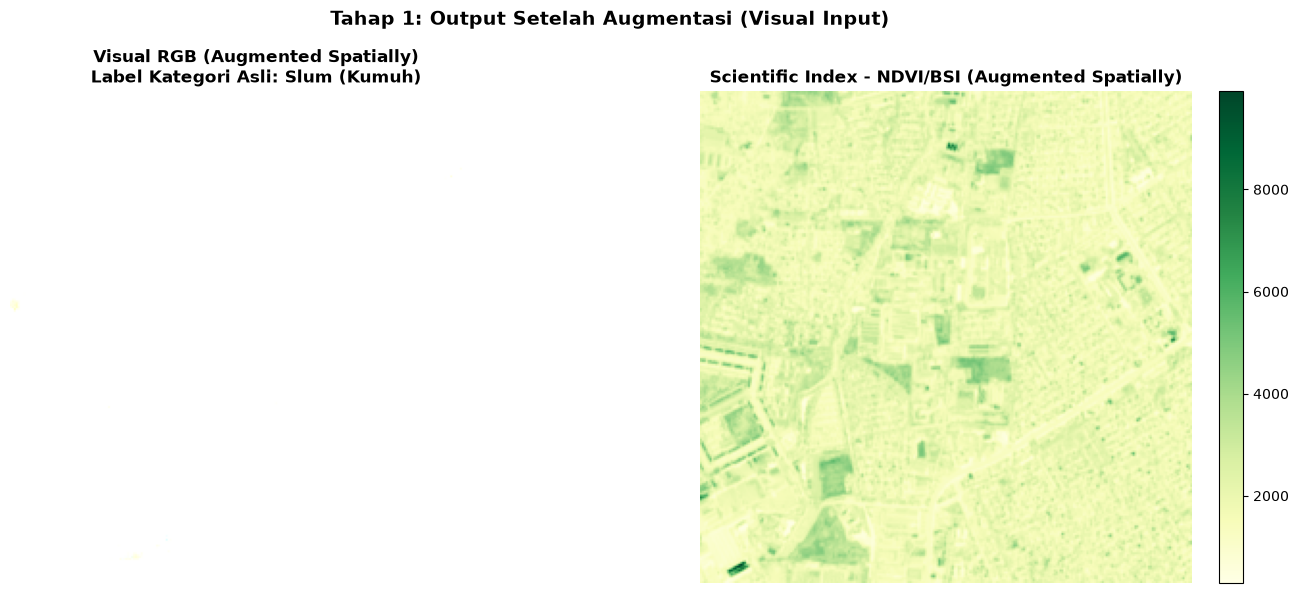

In [3]:
# 1. Baca metadata
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"⚠️ File metadata tidak ditemukan di {METADATA_PATH}")

df_meta = pd.read_csv(METADATA_PATH)

# 2. Filter dataset sesuai pembagiannya
df_train = df_meta[df_meta['split'] == 'train'].copy()
df_val   = df_meta[df_meta['split'] == 'val'].copy()
df_test  = df_meta[df_meta['split'] == 'test'].copy()

print("📊 Distribusi Data Split:")
print(f"Data Training   : {len(df_train)} patch")
print(f"Data Validation : {len(df_val)} patch")
print(f"Data Testing    : {len(df_test)} patch")

# 3. Bungkus ke dalam Custom Dataset kita
train_dataset = UrbanPulseFusionDataset(df_train, PATCHES_DIR, is_train=True)
val_dataset   = UrbanPulseFusionDataset(df_val, PATCHES_DIR, is_train=False)
test_dataset  = UrbanPulseFusionDataset(df_test, PATCHES_DIR, is_train=False)

# 4. Masukkan ke dalam PyTorch DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

# Tes ambil 1 batch untuk memastikan dimensi keluaran sudah benar
sample_rgb, sample_idx, sample_labels = next(iter(train_loader))

print("\n🔍 Inspeksi Bentuk Batch Data:")
print(f"Bentuk Batch RGB            : {sample_rgb.shape} --> (Batch, Channels, Height, Width)")
print(f"Bentuk Batch Indeks Ilmiah  : {sample_idx.shape} --> (Batch, Channels, Height, Width)")
print(f"Bentuk Batch Label          : {sample_labels.shape}")
print("✅ Dataloaders siap disuapkan ke model!")

# =========================================================================
# 📸 TAHAP 1: OUTPUT SETELAH AUGMENTASI (VISUAL INPUT)
# =========================================================================
rgb_augmented = sample_rgb[0].permute(1, 2, 0).numpy()
ndvi_augmented = sample_idx[0][0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tampilkan Gambar RGB Satelit yang mengalami augmentasi spasial (diputar/dibalik)
axes[0].imshow(rgb_augmented)
label_text = "Slum (Kumuh)" if sample_labels[0].item() == 1 else "Non-Slum (Aman)"
axes[0].set_title(f"Visual RGB (Augmented Spatially)\nLabel Kategori Asli: {label_text}", 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Tampilkan Indeks Ilmiah Satelit (NDVI) yang ikut berputar secara sinkron
im = axes[1].imshow(ndvi_augmented, cmap='YlGn')
axes[1].set_title("Scientific Index - NDVI/BSI (Augmented Spatially)", 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Tahap 1: Output Setelah Augmentasi (Visual Input)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## TAHAP 4: ARSITEKTUR FUSION NETWORK (DUA CABANG)
Model ini memiliki struktur *Late Fusion* dengan dua "otak" ahli yang bekerja paralel:
1. **Visual Expert (Branch RGB):** Menggunakan model pra-latih (Pre-trained) **ResNet-18**. Karena ResNet-18 sudah pernah dilatih melihat jutaan gambar, dia sangat pintar mengenali bentuk objek, tekstur atap, dan pola jalan dari data 3-band kita. Kita potong bagian kepalanya (klasifikasinya) agar menghasilkan 512 angka vektor fitur.
2. **Bio-Physical Expert (Branch Indeks):** Menggunakan Custom CNN ringan (3 layer konvolusi). CNN ini dibuat khusus untuk memproses tensor 9-band (NDVI, GLCM, dll) dan merangkumnya menjadi 128 angka vektor fitur.
3. **Fusion Classifier:** Menggabungkan 512 fitur visual + 128 fitur bio-fisik (total 640 fitur) dan memasukkannya ke *Dense Layer* untuk menebak 2 kelas akhir: Slum (1) atau Non-Slum (0).

In [4]:
import torchvision.models as models

class UrbanPulseFusionNet(nn.Module):
    def __init__(self):
        super(UrbanPulseFusionNet, self).__init__()
        
        # ---------------------------------------------------
        # BRANCH 1: VISUAL EXPERT (RGB - 3 Channels)
        # ---------------------------------------------------
        # Menggunakan ResNet18 dengan bobot yang sudah terlatih (Transfer Learning)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Kita buang layer 'fc' (Fully Connected) terakhir milik ResNet
        # Karena kita hanya ingin mengambil fitur gambarnya saja, bukan memprediksi anjing/kucing
        self.rgb_branch = nn.Sequential(*list(resnet.children())[:-1])
        
        # ResNet18 secara standar mengeluarkan 512 dimensi fitur
        self.rgb_out_features = 512 

        # ---------------------------------------------------
        # BRANCH 2: BIO-PHYSICAL EXPERT (Indeks Ilmiah - 9 Channels)
        # ---------------------------------------------------
        # Custom CNN ringan khusus untuk membaca peta bio-fisik dan tekstur
        self.idx_branch = nn.Sequential(
            nn.Conv2d(9, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Ukuran jadi 128x128
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Ukuran jadi 64x64
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Global Average Pooling merangkum seluruh peta spasial menjadi 1 titik angka
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        # Custom CNN kita mengeluarkan 128 dimensi fitur
        self.idx_out_features = 128 

        # ---------------------------------------------------
        # FUSION BLOCK (Penggabungan & Klasifikasi)
        # ---------------------------------------------------
        # 512 (dari RGB) + 128 (dari Indeks) = 640 fitur gabungan
        self.fusion_classifier = nn.Sequential(
            nn.Linear(self.rgb_out_features + self.idx_out_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.4), # Dropout mencegah Overfitting dengan mematikan neuron acak
            nn.Linear(256, 2)  # Output akhir: 2 neuron (0: Non-Slum, 1: Slum)
        )

    def forward(self, rgb_x, idx_x):
        # 1. Ekstrak fitur dari Branch RGB
        rgb_feat = self.rgb_branch(rgb_x)           # Shape: (Batch, 512, 1, 1)
        rgb_feat = torch.flatten(rgb_feat, 1)       # Shape: (Batch, 512)
        
        # 2. Ekstrak fitur dari Branch Indeks
        idx_feat = self.idx_branch(idx_x)           # Shape: (Batch, 128, 1, 1)
        idx_feat = torch.flatten(idx_feat, 1)       # Shape: (Batch, 128)
        
        # 3. PENGGABUNGAN (Concatenate)
        combined_feat = torch.cat((rgb_feat, idx_feat), dim=1) # Shape: (Batch, 640)
        
        # 4. Tebak Kelas Akhir
        out = self.fusion_classifier(combined_feat) # Shape: (Batch, 2)
        return out

# Inisialisasi model dan kirim ke Device (GPU/CPU)
model = UrbanPulseFusionNet().to(device)

# Uji coba forward pass (Simulasi memberi input ke model)
with torch.no_grad():
    sample_rgb = sample_rgb.to(device)
    sample_idx = sample_idx.to(device)
    dummy_output = model(sample_rgb, sample_idx)

print("✅ Arsitektur UrbanPulse Fusion Net Berhasil Dibuat!")
print(f"Dimensi Output Simulasi: {dummy_output.shape} -> (Batch Size, Jumlah Kelas)")

best_model_path = PROCESSED_V2_DIR / "best_urbanpulse_fusion_model.pth"
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("✅ Bobot model terbaik berhasil dimuat ke dalam memori!")
else:
    print("⚠️ File bobot model belum ditemukan. Silakan train model terlebih dahulu.")

✅ Arsitektur UrbanPulse Fusion Net Berhasil Dibuat!
Dimensi Output Simulasi: torch.Size([16, 2]) -> (Batch Size, Jumlah Kelas)
✅ Bobot model terbaik berhasil dimuat ke dalam memori!


## TAHAP 5: TRAINING LOOP & EVALUATION METRICS
Di sinilah proses *Machine Learning* yang sesungguhnya berjalan. 
1. **Fungsi Loss & Optimizer:** Kita menggunakan `CrossEntropyLoss` (standar untuk klasifikasi) dan algoritma `Adam` untuk memperbarui bobot model secara cerdas.
2. **Evaluasi Metrik Ilmiah:** Menggunakan `scikit-learn` untuk menghitung F1-Score dan Cohen's Kappa ($\kappa$) pada data validasi. Model terbaik (*Best Model*) akan disimpan secara otomatis berdasarkan nilai Loss Validasi terendah.

In [5]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, cohen_kappa_score
import time

# 1. Definisikan Loss (Fungsi Hukuman) dan Optimizer (Algoritma Belajar)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Variabel untuk melacak model terbaik
best_val_loss = float('inf')
best_model_path = PROCESSED_V2_DIR / "best_urbanpulse_fusion_model.pth"

# 2. Fungsi pembantu untuk menghitung metrik statistik
def calculate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    # average='macro' agar adil menghitung rata-rata performa kedua kelas
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    return acc, precision, recall, f1, kappa

print(f"Mulai proses training selama {EPOCHS} Epochs...")
print("-" * 60)

# 3. TRAINING LOOP UTAMA
for epoch in range(EPOCHS):
    start_time = time.time()
    
    # -- TAHAP TRAINING --
    model.train() # Mode belajar aktif
    train_loss = 0.0
    
    # Gunakan tqdm untuk progress bar yang cantik
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for rgb_batch, idx_batch, labels in train_bar:
        # Pindahkan data ke GPU (jika aktif)
        rgb_batch = rgb_batch.to(device)
        idx_batch = idx_batch.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad() # Bersihkan ingatan kesalahan sebelumnya
        
        # Forward Pass (Menebak)
        outputs = model(rgb_batch, idx_batch)
        loss = criterion(outputs, labels) # Hitung kesalahan
        
        # Backward Pass (Belajar & Update Bobot)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    avg_train_loss = train_loss / len(train_loader)
    
    # -- TAHAP VALIDASI (Ujian Tengah Semester) --
    model.eval() # Mode evaluasi (model tidak belajar/update bobot)
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  ")
    with torch.no_grad(): # Matikan perhitungan gradien agar hemat memori
        for rgb_batch, idx_batch, labels in val_bar:
            rgb_batch = rgb_batch.to(device)
            idx_batch = idx_batch.to(device)
            labels = labels.to(device)
            
            outputs = model(rgb_batch, idx_batch)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            # Ambil tebakan final (index dengan probabilitas tertinggi)
            _, preds = torch.max(outputs, 1)
            
            # Simpan hasil untuk dihitung metriknya nanti
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader)
    
    # Hitung metrik statistik validasi
    val_acc, val_prec, val_rec, val_f1, val_kappa = calculate_metrics(all_labels, all_preds)
    
    time_elapsed = time.time() - start_time
    
    # Tampilkan hasil epoch ini
    print(f"\nRingkasan Epoch {epoch+1}:")
    print(f"⏱️ Waktu     : {time_elapsed:.2f} detik")
    print(f"📉 Train Loss: {avg_train_loss:.4f} | 📈 Val Loss: {avg_val_loss:.4f}")
    print(f"📊 Val Stats : Acc: {val_acc:.4f} | F1: {val_f1:.4f} | Kappa: {val_kappa:.4f}")
    
    # -- SIMPAN MODEL TERBAIK --
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"🌟 Model terbaik baru disimpan! (Val Loss menurun)")
    print("-" * 60)

print(f"🎉 Training Selesai! Model terbaik tersimpan di: {best_model_path}")

Mulai proses training selama 30 Epochs...
------------------------------------------------------------


Epoch 1/30 [Val]  : 100%|██████████| 290/290 [08:55<00:00,  1.85s/it]



Ringkasan Epoch 1:
⏱️ Waktu     : 2788.86 detik
📉 Train Loss: 0.0411 | 📈 Val Loss: 0.2202
📊 Val Stats : Acc: 0.9323 | F1: 0.9267 | Kappa: 0.8537
🌟 Model terbaik baru disimpan! (Val Loss menurun)
------------------------------------------------------------


Epoch 2/30 [Val]  : 100%|██████████| 290/290 [07:55<00:00,  1.64s/it]



Ringkasan Epoch 2:
⏱️ Waktu     : 2585.68 detik
📉 Train Loss: 0.0340 | 📈 Val Loss: 0.2357
📊 Val Stats : Acc: 0.9228 | F1: 0.9159 | Kappa: 0.8324
------------------------------------------------------------


...


Ringkasan Epoch 28:
⏱️ Waktu     : 2554.58 detik
📉 Train Loss: 0.0135 | 📈 Val Loss: 0.0959
📊 Val Stats : Acc: 0.9694 | F1: 0.9674 | Kappa: 0.9347
------------------------------------------------------------


Epoch 29/30 [Val]  : 100%|██████████| 290/290 [07:55<00:00,  1.64s/it]



Ringkasan Epoch 29:
⏱️ Waktu     : 2544.66 detik
📉 Train Loss: 0.0156 | 📈 Val Loss: 0.0938
📊 Val Stats : Acc: 0.9631 | F1: 0.9613 | Kappa: 0.9226
------------------------------------------------------------


Epoch 30/30 [Val]  : 100%|██████████| 290/290 [07:58<00:00,  1.65s/it]


Ringkasan Epoch 30:
⏱️ Waktu     : 2560.69 detik
📉 Train Loss: 0.0146 | 📈 Val Loss: 0.1337
📊 Val Stats : Acc: 0.9458 | F1: 0.9438 | Kappa: 0.8879
------------------------------------------------------------
🎉 Training Selesai! Model terbaik tersimpan di: ..\data\processed_v2\best_urbanpulse_fusion_model.pth


In [5]:
import pandas as pd
from pathlib import Path

# Arahkan ke file metadata sesuai struktur foldermu
METADATA_PATH = Path("../data/processed_v2/dataset_metadata_final_v2.csv")

# Baca file CSV
df_meta = pd.read_csv(METADATA_PATH)

# Tampilkan daftar kolom dan contoh isinya
print("🔍 Daftar Kolom di Metadata:")
print(df_meta.columns.tolist())
print("\nContoh 3 baris pertama:")
print(df_meta.head(3)) # <-- Menggunakan print biasa sebagai pengganti display

🔍 Daftar Kolom di Metadata:
['patch_id', 'patch_filename', 'source_img', 'origin_row', 'origin_col', 'category', 'split', 'mean_build', 'mean_ndvi', 'mean_water', 'mean_mndwi', 'mean_bsi', 'glcm_contrast']

Contoh 3 baris pertama:
               patch_id            patch_filename  \
0  patch_non-slum_00000  patch_non-slum_00000.tif   
1  patch_non-slum_00001  patch_non-slum_00001.tif   
2      patch_slum_00002      patch_slum_00002.tif   

                                          source_img  origin_row  origin_col  \
0  Dataset_Multimodal_Slum_Jabar_2025_Fixed-00000...        5888        2560   
1  Dataset_Multimodal_Slum_Jabar_2025_Fixed-00000...        7936        4864   
2  Dataset_Multimodal_Slum_Jabar_2025_Fixed-00000...         640        1984   

   category  split  mean_build  mean_ndvi  mean_water  mean_mndwi  mean_bsi  \
0  non-slum  train         NaN        NaN         NaN         NaN       NaN   
1  non-slum  train         NaN        NaN         NaN         NaN       NaN  

In [6]:
# Menggunakan 'source_img' sebagai penanda asal wilayah
KOLOM_INDUK = 'source_img' 

# Pisahkan dataset berdasarkan split
df_train = df_meta[df_meta['split'] == 'train']
df_val   = df_meta[df_meta['split'] == 'val']

# Ambil himpunan (set) gambar induk unik dari masing-masing split
train_sources = set(df_train[KOLOM_INDUK].unique())
val_sources   = set(df_val[KOLOM_INDUK].unique())

# Cari irisannya (intersection)
bocor = train_sources.intersection(val_sources)

print("-" * 50)
print(f"Total wilayah induk di Train : {len(train_sources)}")
print(f"Total wilayah induk di Val   : {len(val_sources)}")
print(f"Jumlah wilayah yang OVERLAP  : {len(bocor)}")
print("-" * 50)

if len(bocor) > 0:
    print(f"⚠️ TERDETEKSI DATA LEAKAGE! Ada {len(bocor)} gambar induk yang bocor ke Train dan Val sekaligus.")
    print("Contoh wilayah yang bocor:\n", list(bocor)[:5])
    print("\nKesimpulan: Kita perlu kembali ke '01_preprocessing.ipynb' untuk memperbaiki strategi split-nya.")
else:
    print("✅ AMAN! Tidak ada kebocoran data antar wilayah.")

--------------------------------------------------
Total wilayah induk di Train : 5
Total wilayah induk di Val   : 1
Jumlah wilayah yang OVERLAP  : 0
--------------------------------------------------
✅ AMAN! Tidak ada kebocoran data antar wilayah.


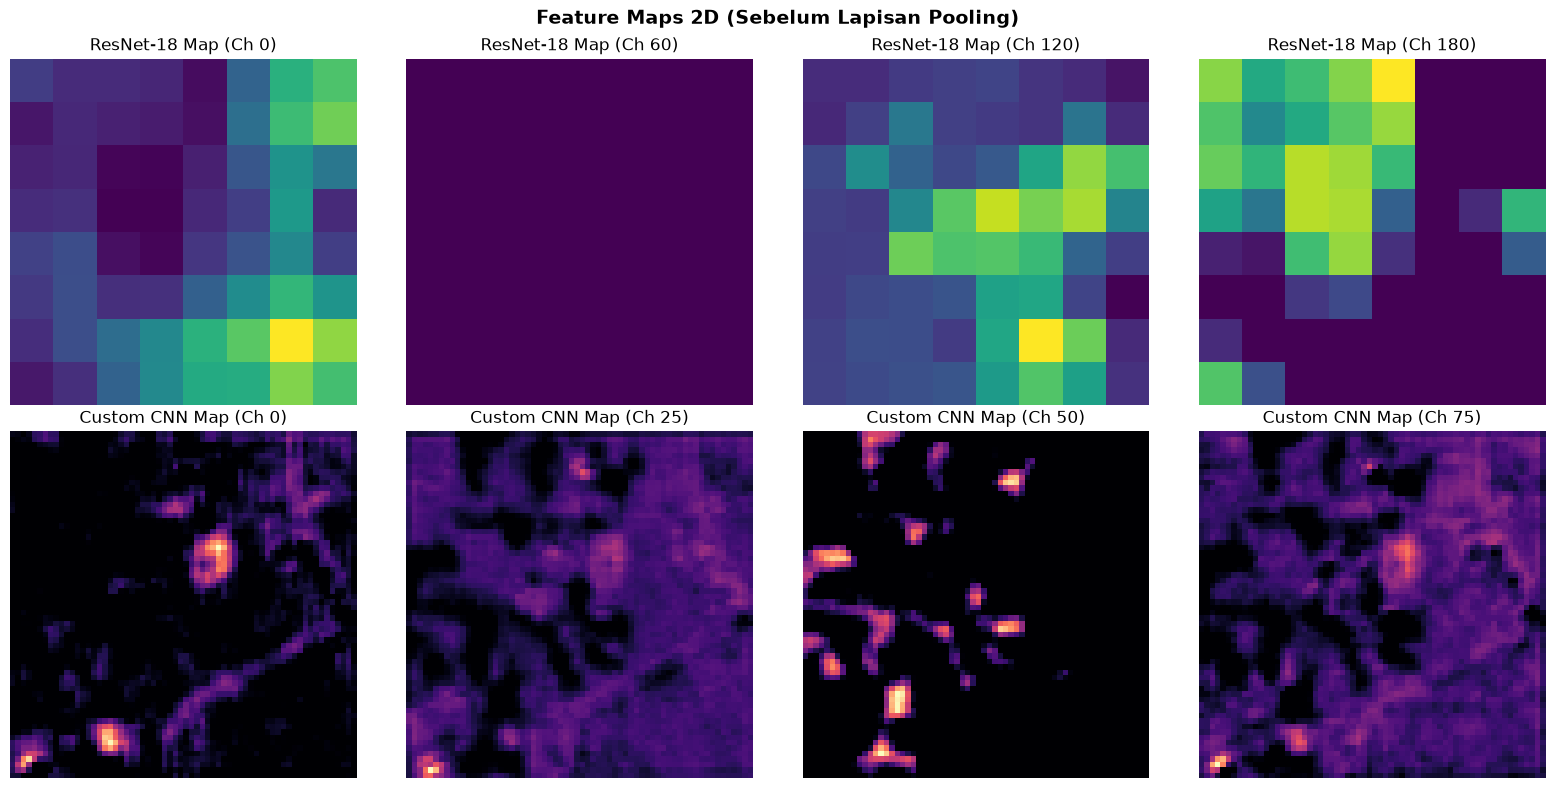

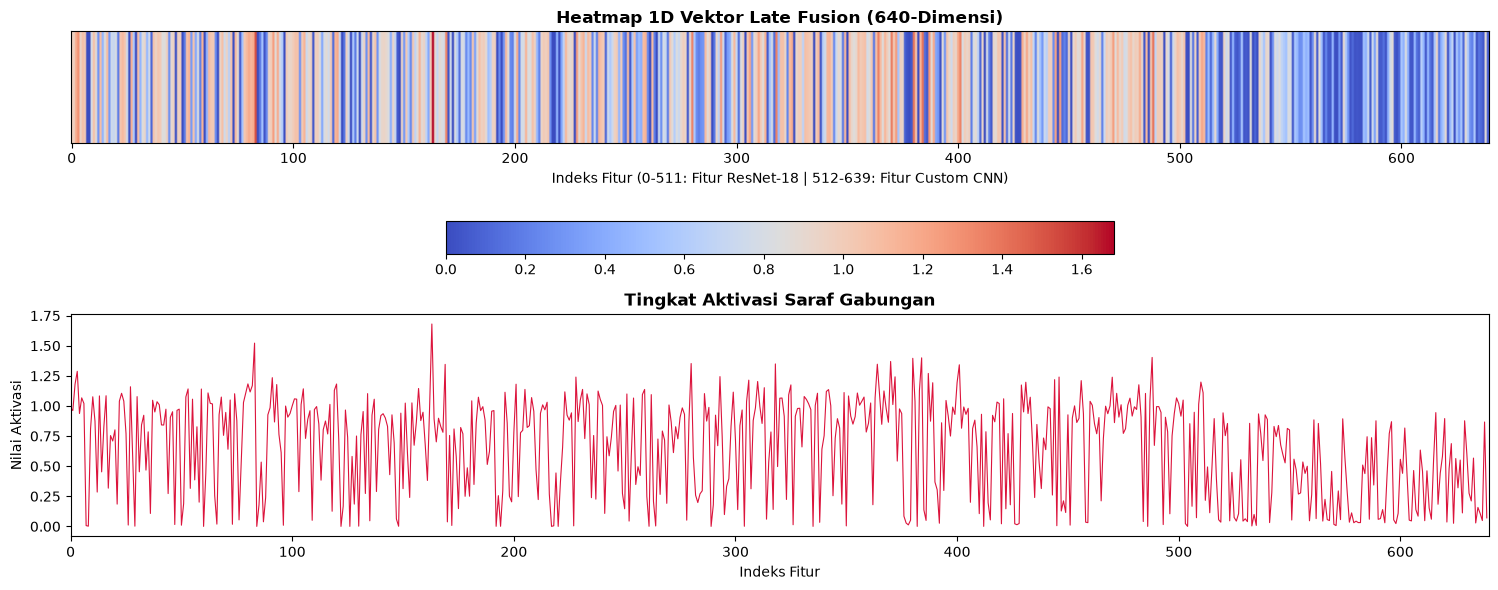

In [7]:
# =========================================================================
# ⚙️ PREPARASI INPUT & MODEL
# =========================================================================
# Set model ke mode evaluasi agar Batch Normalization & Dropout tidak aktif
model.eval()

# Ambil sampel pertama dari loader untuk divisualisasikan
x_rgb = sample_rgb[0:1].to(device)
x_idx = sample_idx[0:1].to(device)
true_label = sample_labels[0].item()

# =========================================================================
# 🧠 TAHAP 2: FEATURE MAPS (ResNet-18 & Custom CNN)
# =========================================================================
# Ekstrak feature map sebelum layer pooling dari Branch RGB (ResNet-18)
feat_map_rgb = x_rgb
for i in range(8):
    feat_map_rgb = model.rgb_branch[i](feat_map_rgb)
feat_map_rgb_np = feat_map_rgb.squeeze(0).detach().cpu().numpy() # Shape: (512, 8, 8)

# Ekstrak feature map sebelum layer pooling dari Branch Indeks (Custom CNN)
feat_map_idx = x_idx
for i in range(11):
    feat_map_idx = model.idx_branch[i](feat_map_idx)
feat_map_idx_np = feat_map_idx.squeeze(0).detach().cpu().numpy() # Shape: (128, 64, 64)

# Plot Feature Maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    ch = i * 60  # Pilih channel bervariasi dari ResNet-18 (0, 60, 120, 180)
    axes[0, i].imshow(feat_map_rgb_np[ch], cmap='viridis')
    axes[0, i].set_title(f"ResNet-18 Map (Ch {ch})")
    axes[0, i].axis('off')

for i in range(4):
    ch = i * 25  # Pilih channel bervariasi dari Custom CNN (0, 25, 50, 75)
    axes[1, i].imshow(feat_map_idx_np[ch], cmap='magma')
    axes[1, i].set_title(f"Custom CNN Map (Ch {ch})")
    axes[1, i].axis('off')

plt.suptitle("Feature Maps 2D (Sebelum Lapisan Pooling)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================================================
# 🔗 TAHAP 3: OUTPUT LATE FUSION (Vektor Gabungan 1D)
# =========================================================================
with torch.no_grad():
    rgb_feat = model.rgb_branch(x_rgb)
    rgb_feat = torch.flatten(rgb_feat, 1)  # Shape: (1, 512)
    
    idx_feat = model.idx_branch(x_idx)
    idx_feat = torch.flatten(idx_feat, 1)  # Shape: (1, 128)

    combined_feat = torch.cat((rgb_feat, idx_feat), dim=1)  # Shape: (1, 640)
combined_vector = combined_feat.squeeze(0).cpu().numpy()

# Plot Heatmap 1D dan Grafik Aktivasi Saraf Gabungan
plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plt.imshow(combined_vector.reshape(1, -1), aspect='auto', cmap='coolwarm')
plt.title("Heatmap 1D Vektor Late Fusion (640-Dimensi)", fontsize=12, fontweight='bold')
plt.yticks([])
plt.xlabel("Indeks Fitur (0-511: Fitur ResNet-18 | 512-639: Fitur Custom CNN)")
plt.colorbar(orientation='horizontal', pad=0.35)

plt.subplot(2, 1, 2)
plt.plot(combined_vector, color='crimson', linewidth=0.8)
plt.title("Tingkat Aktivasi Saraf Gabungan", fontsize=12, fontweight='bold')
plt.xlim(0, len(combined_vector))
plt.ylabel("Nilai Aktivasi")
plt.xlabel("Indeks Fitur")
plt.tight_layout()
plt.show()
